# Project Overview

This project implements a Convolutional Neural Network (CNN) to predict a person's gender and age from facial images using the UTKFace dataset. The model is built with TensorFlow and Keras, demonstrating the application of deep learning techniques in computer vision for facial attribute prediction.

## Objectives
Develop a CNN model for gender classification and age prediction.
Preprocess and prepare the UTKFace dataset for training.
Train and evaluate the model using TensorFlow and Keras.
Analyze the model's performance and visualize the prediction results.

## Technologies Used
Python
TensorFlow
Keras
NumPy
Pandas
Matplotlib

## Dataset
The model is trained on the UTKFace dataset, which contains over 20,000 face images spanning a wide range of ages, genders, and ethnicities. Each image is labeled with age, gender, and ethnicity, making it a popular benchmark dataset for facial attribute prediction.

## Workflow
Import required libraries.
Load and preprocess the UTKFace dataset.
Build the CNN model using TensorFlow and Keras.
Train and validate the model.
Evaluate the model's performance.
Visualize predictions on sample images.

## About This Project
This is my first deep learning project, created to strengthen my understanding of TensorFlow, Keras, Convolutional Neural Networks (CNNs), and computer vision by solving a real-world image prediction problem.

### Import Modules

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline

import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input

### Load the Dataset

In [4]:
BASE_DIR = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/'

In [5]:
# label = age, gender, ethnicity
image_paths = []
age_labels =[]
gender_labels = []

for filename in tqdm(os.listdir(BASE_DIR)):
    image_path = os.path.join(BASE_DIR, filename)
    temp = filename.split('_')
    age = int(temp[0])
    gender = int(temp[1])
    image_paths.append(image_path)
    age_labels.append(age)
    gender_labels.append(gender)

  0%|          | 0/23708 [00:00<?, ?it/s]

In [6]:
#Convert to dataframe
df = pd.DataFrame()
df['image'], df['age'], df['gender'] = image_paths, age_labels, gender_labels
df.head()

,image,age,gender
0,/kaggle/input/datasets/jangedoo/utkface-new/UT...,26,0
1,/kaggle/input/datasets/jangedoo/utkface-new/UT...,22,1
2,/kaggle/input/datasets/jangedoo/utkface-new/UT...,21,1
3,/kaggle/input/datasets/jangedoo/utkface-new/UT...,28,0
4,/kaggle/input/datasets/jangedoo/utkface-new/UT...,17,1


In [7]:
# map labels for gender
gender_dict = {0:'Male', 1:'Female'}

### Exploratory Data Analysis

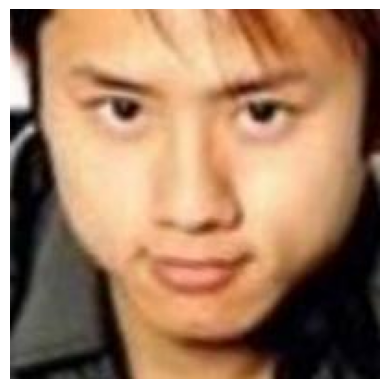

In [8]:
from PIL import Image
img = Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img);

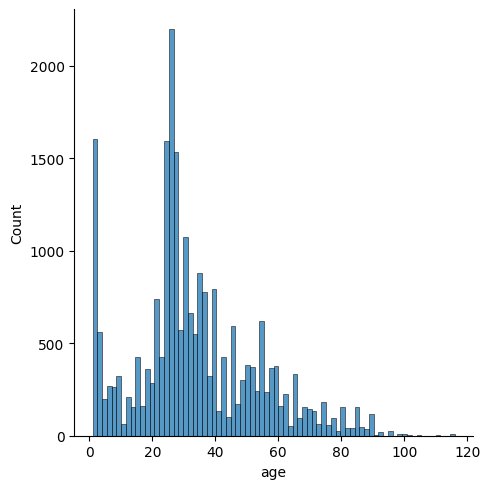

In [9]:
sns.displot(df['age'])

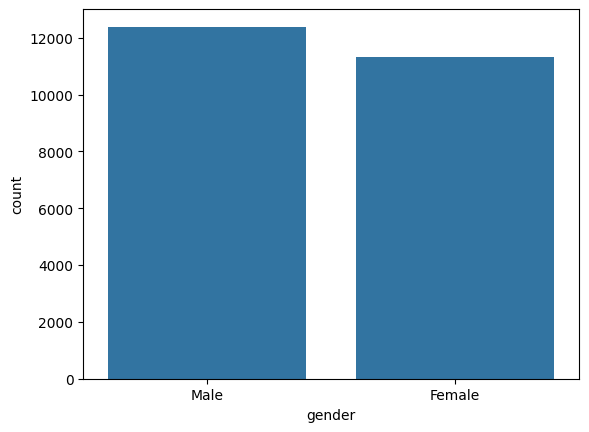

In [10]:
df['gender'] = df['gender'].map({0: 'Male', 1: 'Female'})

sns.countplot(data=df, x='gender')
plt.show()

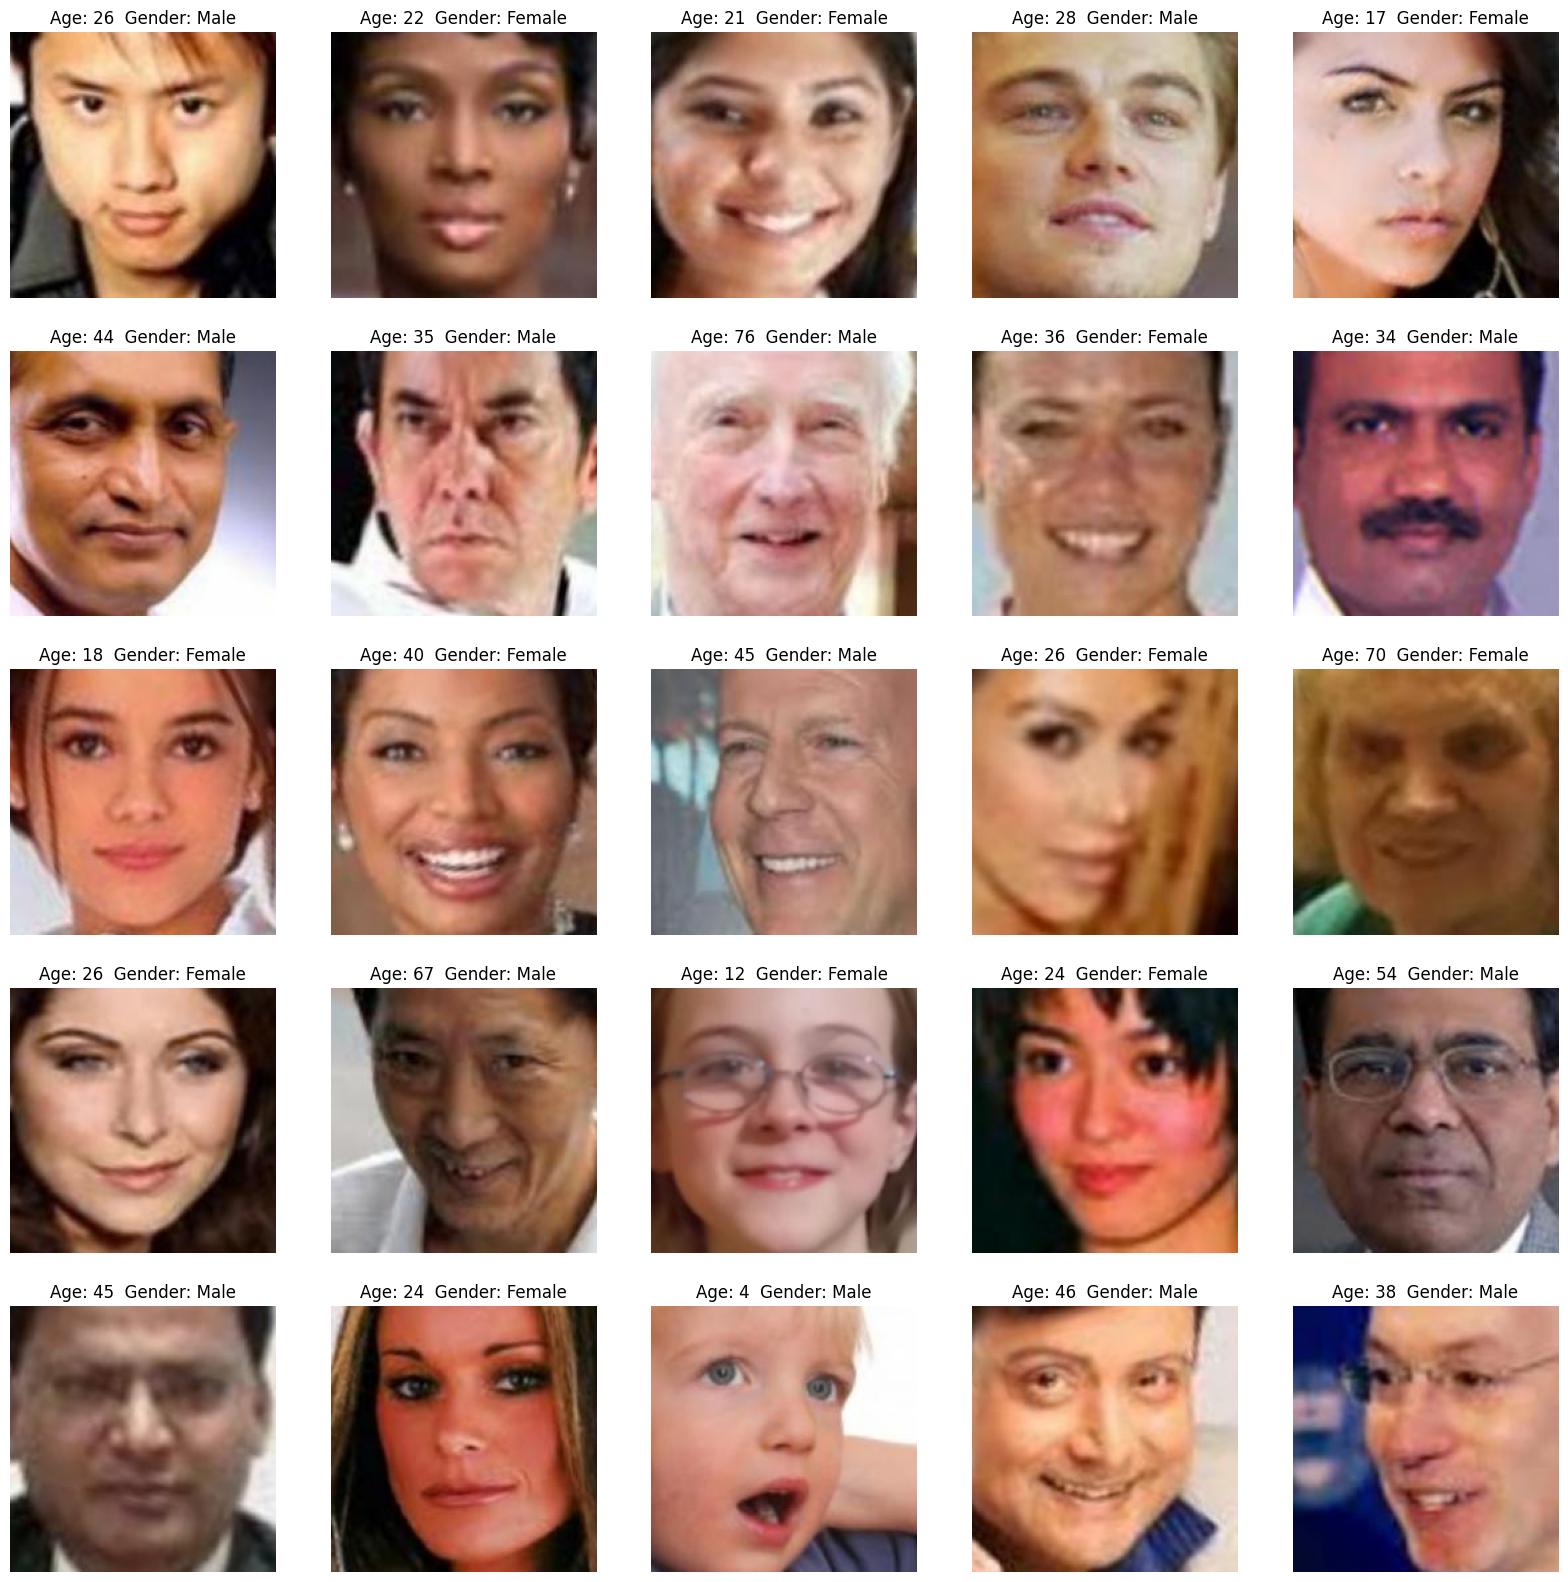

In [11]:
#to display grid of images
plt.figure(figsize =(20,20))
files = df.iloc[0:25]

for index, file, age, gender in files.itertuples():
    plt.subplot(5, 5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title(f"Age: {age}  Gender: {gender}")
    plt.axis('off')

### Extracting Features

In [12]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def extract_Features(images):
    features = []

    for image in images:
        img = load_img(
            image,
            color_mode='grayscale',
            target_size=(128, 128)
        )
        img = img_to_array(img)
        features.append(img)

    return np.array(features, dtype=np.float32)

In [13]:
X = extract_Features(df['image'])

In [14]:
X.shape

(23708, 128, 128, 1)

In [15]:
#normalize the images
X = X/255.0

In [16]:
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])

In [17]:
input_shape = (128, 128, 1)

### Model Creation

In [18]:
inputs = Input((input_shape))
# convolutional layers
conv_1 = Conv2D(32, kernel_size = (3,3), activation = 'relu') (inputs)
maxp_1 = MaxPooling2D(pool_size = (2,2)) (conv_1)
conv_2 = Conv2D(64, kernel_size = (3,3), activation = 'relu') (maxp_1)
maxp_2 = MaxPooling2D(pool_size = (2,2)) (conv_2)
conv_3 = Conv2D(128, kernel_size = (3,3), activation = 'relu') (maxp_2)
maxp_3 = MaxPooling2D(pool_size = (2,2)) (conv_3)
conv_4 = Conv2D(256, kernel_size = (3,3), activation = 'relu') (maxp_3)
maxp_4 = MaxPooling2D(pool_size = (2,2)) (conv_4)

flatten = Flatten() (maxp_4)

#fully connected layers
dense_1 = Dense(256, activation='relu') (flatten)
dense_2 = Dense(256, activation='relu') (flatten)

dropout_1 = Dropout(0.3) (dense_1)
dropout_2 = Dropout(0.3) (dense_2)

output_1 = Dense(1, activation='sigmoid', name='gender_out') (dropout_1)
output_2 = Dense(1, activation='relu', name='age_out') (dropout_2)

model = Model(inputs=[inputs], outputs=[output_1, output_2])

model.compile(
    optimizer='adam',
    loss={
        'gender_out': 'binary_crossentropy',
        'age_out': 'mae'
    },
    metrics={
        'gender_out': 'accuracy',
        'age_out': 'mae'
    }
)

I0000 00:00:1783253996.814996      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783253996.817819      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


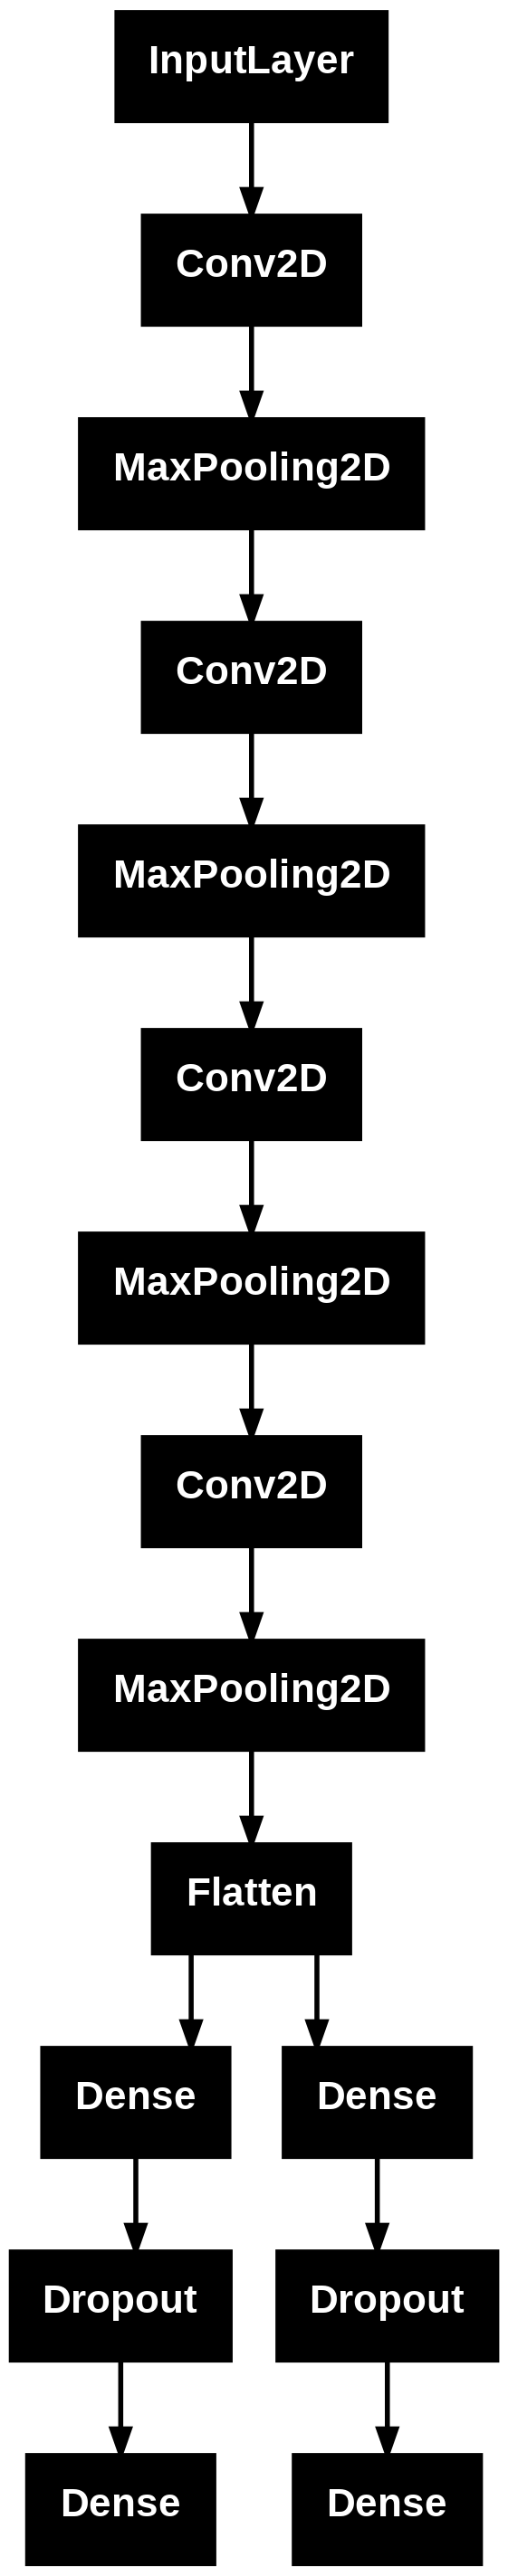

In [19]:
#plot the model
from tensorflow.keras.utils import plot_model
plot_model(model)

In [20]:
y_gender = np.where(y_gender == 'Male', 0, 1).astype(np.float32)

In [21]:
# train model
history = model.fit(
    x=X,
    y=[y_gender, y_age],
    batch_size=32,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30


2026-07-05 12:20:06.881227: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 12:20:07.030403: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  7/593 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - age_out_loss: 33.2927 - age_out_mae: 33.2927 - gender_out_accuracy: 0.5426 - gender_out_loss: 0.8404 - loss: 34.1331

I0000 00:00:1783254010.128684     531 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


593/593 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - age_out_loss: 14.9367 - age_out_mae: 14.9390 - gender_out_accuracy: 0.5637 - gender_out_loss: 0.6743 - loss: 15.6135 - val_age_out_loss: 11.6154 - val_age_out_mae: 11.5881 - val_gender_out_accuracy: 0.7343 - val_gender_out_loss: 0.5339 - val_loss: 12.1203
Epoch 2/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - age_out_loss: 11.0815 - age_out_mae: 11.0827 - gender_out_accuracy: 0.7661 - gender_out_loss: 0.4869 - loss: 11.5696 - val_age_out_loss: 10.2134 - val_age_out_mae: 10.2065 - val_gender_out_accuracy: 0.7997 - val_gender_out_loss: 0.4257 - val_loss: 10.6322
Epoch 3/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - age_out_loss: 9.2779 - age_out_mae: 9.2776 - gender_out_accuracy: 0.8121 - gender_out_loss: 0.4048 - loss: 9.6825 - val_age_out_loss: 8.3319 - val_age_out_mae: 8.3268 - val_gender_out_accuracy: 0.8195 - val_gender_out_loss: 0.3685 - val_loss: 8.6960
Epoch 4/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - age_out_loss: 8.2718 - ag

In [22]:
print(type(X))
print(X.shape)
print(X.dtype)
print(X[0])

<class 'numpy.ndarray'>
(23708, 128, 128, 1)
float32
[[[0.05098039]
  [0.02352941]
  [0.02745098]
  ...
  [0.12941177]
  [0.16862746]
  [0.19607843]]

 [[0.0627451 ]
  [0.01176471]
  [0.01568628]
  ...
  [0.08235294]
  [0.12156863]
  [0.1764706 ]]

 [[0.07843138]
  [0.00784314]
  [0.00784314]
  ...
  [0.06666667]
  [0.10588235]
  [0.1764706 ]]

 ...

 [[0.1764706 ]
  [0.12941177]
  [0.09411765]
  ...
  [0.01568628]
  [0.01568628]
  [0.01960784]]

 [[0.16078432]
  [0.10980392]
  [0.07450981]
  ...
  [0.00784314]
  [0.01176471]
  [0.02352941]]

 [[0.20392157]
  [0.14509805]
  [0.10196079]
  ...
  [0.        ]
  [0.01176471]
  [0.03921569]]]


In [23]:
print(type(X))
print(X.shape)
print(X.dtype)

print(type(y_gender), y_gender.dtype, y_gender.shape)
print(type(y_age), y_age.dtype, y_age.shape)
print(X[0])

<class 'numpy.ndarray'>
(23708, 128, 128, 1)
float32
<class 'numpy.ndarray'> float32 (23708,)
<class 'numpy.ndarray'> int64 (23708,)
[[[0.05098039]
  [0.02352941]
  [0.02745098]
  ...
  [0.12941177]
  [0.16862746]
  [0.19607843]]

 [[0.0627451 ]
  [0.01176471]
  [0.01568628]
  ...
  [0.08235294]
  [0.12156863]
  [0.1764706 ]]

 [[0.07843138]
  [0.00784314]
  [0.00784314]
  ...
  [0.06666667]
  [0.10588235]
  [0.1764706 ]]

 ...

 [[0.1764706 ]
  [0.12941177]
  [0.09411765]
  ...
  [0.01568628]
  [0.01568628]
  [0.01960784]]

 [[0.16078432]
  [0.10980392]
  [0.07450981]
  ...
  [0.00784314]
  [0.01176471]
  [0.02352941]]

 [[0.20392157]
  [0.14509805]
  [0.10196079]
  ...
  [0.        ]
  [0.01176471]
  [0.03921569]]]


In [24]:
print(y_gender[:10])
print(pd.Series(y_gender).unique())

[0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
[0. 1.]


### Plot the Results

<Figure size 640x480 with 0 Axes>

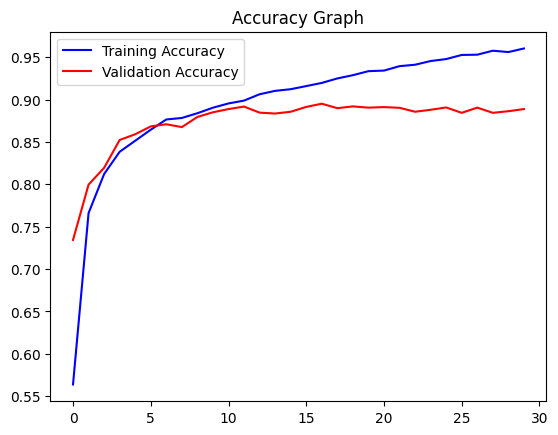

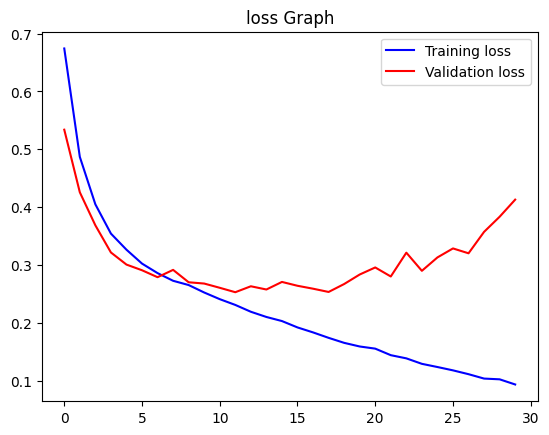

<Figure size 640x480 with 0 Axes>

In [26]:
#Plot result for gender
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label = 'Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['gender_out_loss']
val_loss = history.history['val_gender_out_loss']

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation loss')
plt.title('loss Graph')
plt.legend()
plt.figure()


<Figure size 640x480 with 0 Axes>

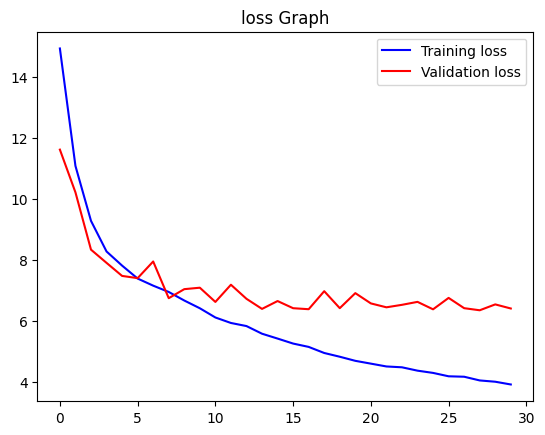

<Figure size 640x480 with 0 Axes>

In [27]:
#plot results for age
loss = history.history['age_out_loss']
val_loss = history.history['val_age_out_loss']
epochs = range(len(acc))


plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation loss')
plt.title('loss Graph')
plt.legend()
plt.figure()

### Prediction with Test Data

Original Gender : Female Original Age: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted GEnder : Female Predicted Age: 0


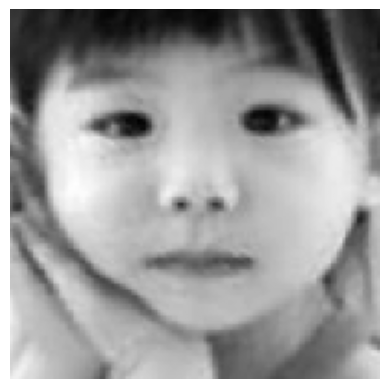

In [31]:
image_index = 100
print("Original Gender :", gender_dict[y_gender[image_index]], "Original Age:" , y_age[image_index])
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])
print("Predicted GEnder :", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');

Original Gender : Male Original Age: 42
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Gender : Male Predicted Age: 34


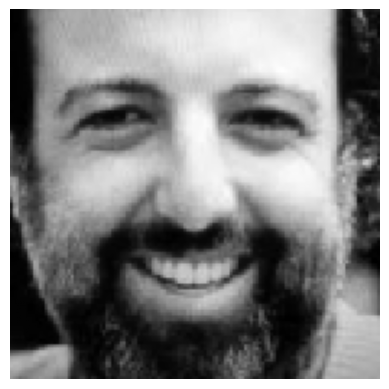

In [34]:
image_index = 10000
print("Original Gender :", gender_dict[y_gender[image_index]], "Original Age:" , y_age[image_index])
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])
print("Predicted Gender :", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');